# Import Libraries

In [2]:

# NOTEBOOK 3: EDA & VISUALIZATION
# EcoType - Forest Cover Type Prediction
 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Makes plots look nicer
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print(" All libraries imported successfully!")

 All libraries imported successfully!


# Load Cleaned Dataset

In [5]:
# Load the CLEANED dataset

df = pd.read_csv('../data/forest_cover_cleaned.csv')

print(f"Cleaned dataset loaded! Shape: {df.shape}")
df.head()

Cleaned dataset loaded! Shape: (145890, 13)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51,3,258.0,0,510,221.0,232,148,6279,Aspen,1,29
1,2590.0,56,2,212.0,-6,390,220.0,235,151,6225,Aspen,1,29
2,2804.0,139,9,268.0,65,3180,234.0,238,135,6121,Lodgepole Pine,1,12
3,2785.0,155,18,242.0,117,3090,238.0,238,122,6211,Lodgepole Pine,1,30
4,2595.0,45,2,153.0,-1,391,220.0,234,150,6172,Aspen,1,29


# Define Column Groups

In [8]:
# Same column grouping 

target_col = 'Cover_Type'
categorical_cols = ['Wilderness_Area', 'Soil_Type']
numerical_cols = [col for col in df.columns 
                  if col not in categorical_cols + [target_col]]

print(" Numerical columns:", numerical_cols)
print(" Categorical columns:", categorical_cols)
print(" Target column:", target_col)

 Numerical columns: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
 Categorical columns: ['Wilderness_Area', 'Soil_Type']
 Target column: Cover_Type


#  Class Distribution (Target Variable)

C:\Users\nihmath\AppData\Local\Temp\ipykernel_10068\213366394.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Cover_Type', data=df, palette='viridis',


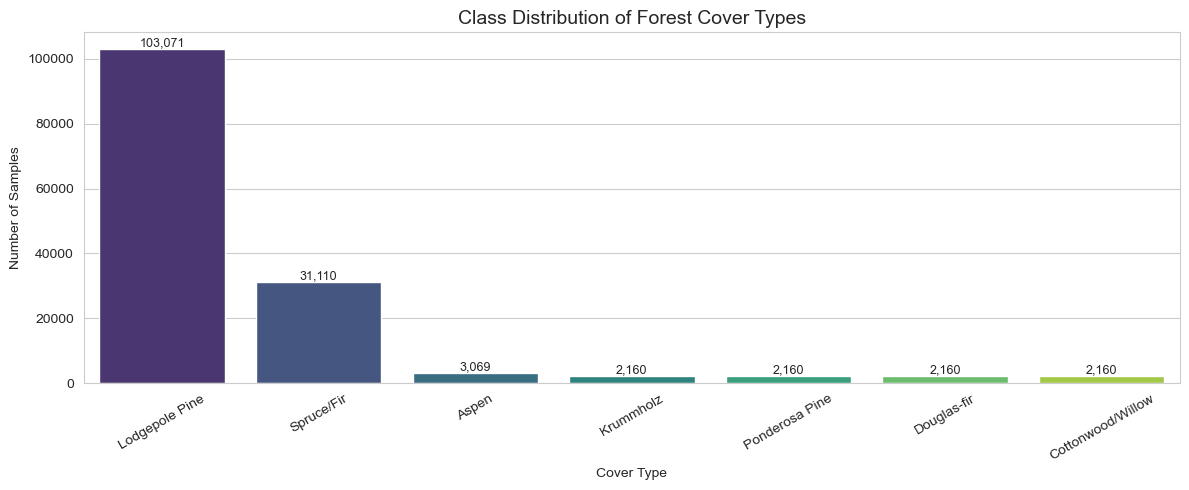

In [11]:
# Visualize how many samples each forest type has

plt.figure(figsize=(12, 5))

ax = sns.countplot(x='Cover_Type', data=df, palette='viridis',
                   order=df['Cover_Type'].value_counts().index)

# Add count numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Class Distribution of Forest Cover Types', fontsize=14)
plt.xlabel('Cover Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Distribution of All Numerical Features

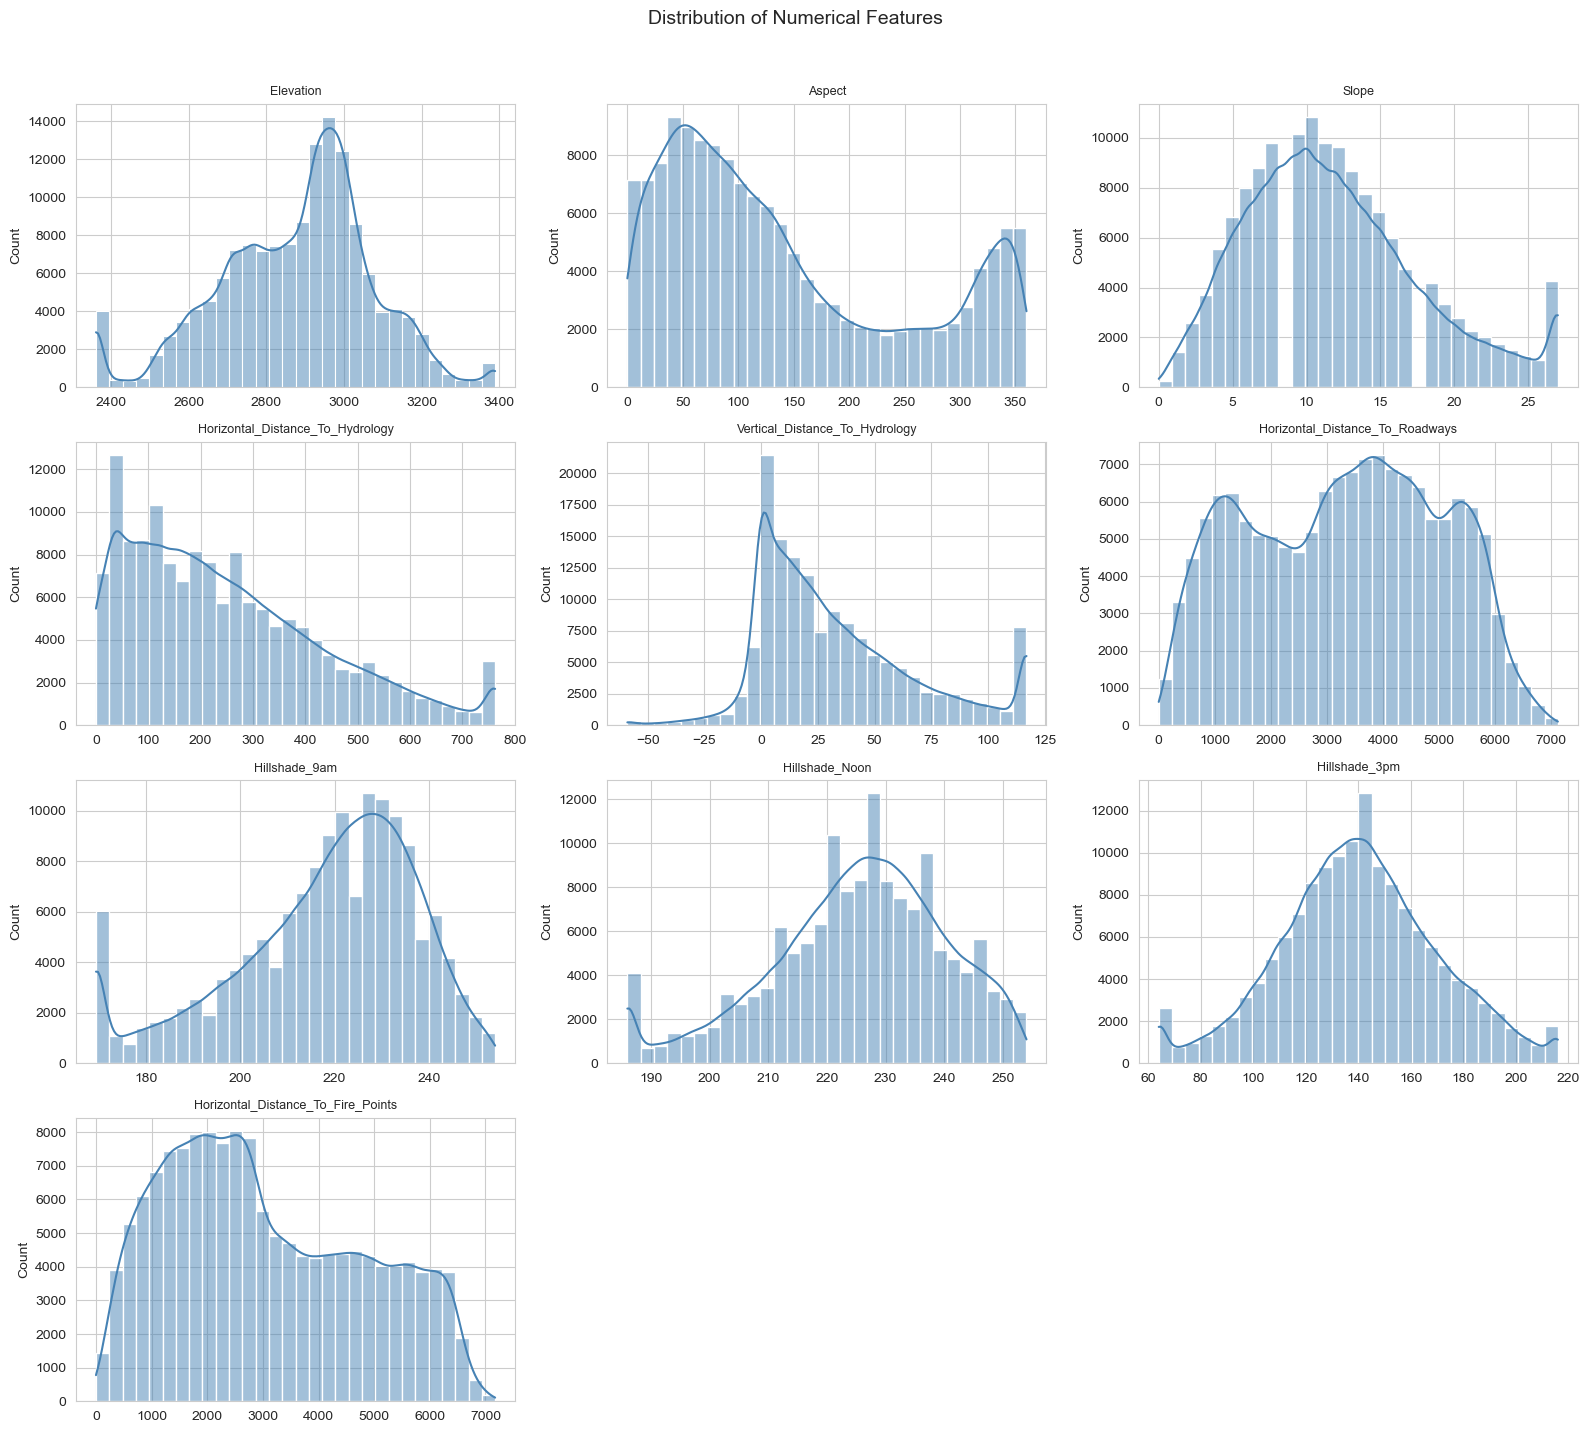

In [14]:
# Histogram for each numerical column
# Shows how values are spread/distributed

plt.figure(figsize=(16, 14))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, color='steelblue', bins=30)
    plt.title(f'{col}', fontsize=9)
    plt.xlabel('')
    plt.tight_layout()

plt.suptitle('Distribution of Numerical Features', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Boxplot by Cover Type (Elevation)

C:\Users\nihmath\AppData\Local\Temp\ipykernel_10068\2473481068.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y='Elevation', data=df, palette='viridis')


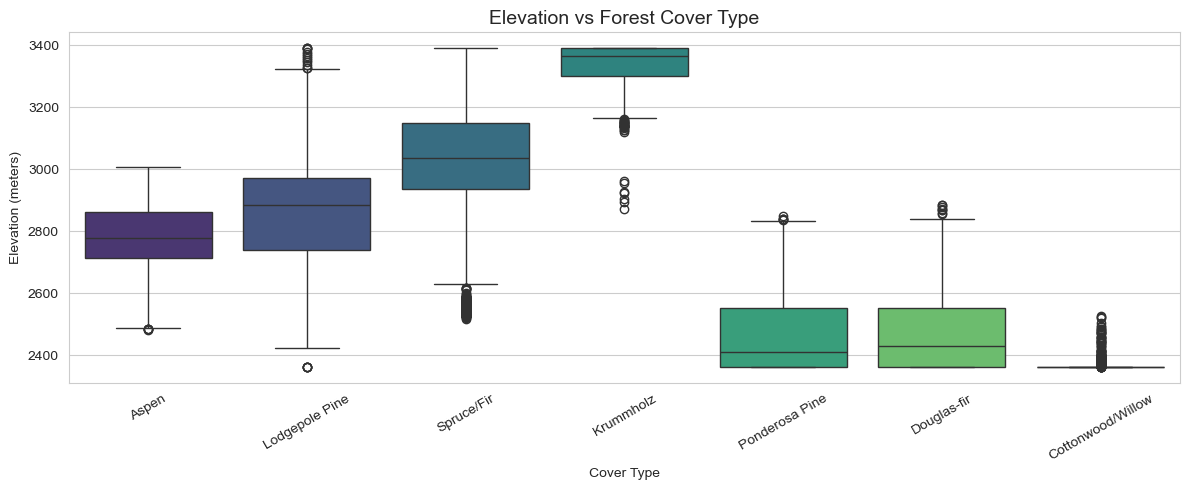

In [17]:
# Elevation is usually the most important feature
# Let's see how elevation differs across forest types

plt.figure(figsize=(12, 5))
sns.boxplot(x='Cover_Type', y='Elevation', data=df, palette='viridis')
plt.title('Elevation vs Forest Cover Type', fontsize=14)
plt.xlabel('Cover Type')
plt.ylabel('Elevation (meters)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot by Cover Type (All Numerical Features)

C:\Users\nihmath\AppData\Local\Temp\ipykernel_10068\2823864725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df,
C:\Users\nihmath\AppData\Local\Temp\ipykernel_10068\2823864725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df,
C:\Users\nihmath\AppData\Local\Temp\ipykernel_10068\2823864725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y=col, data=df,
C:\Users\nihmath\AppData\Local\Temp\ipykernel_10068\2823864725.py:7: FutureWarning: 

Passing `palette` wi

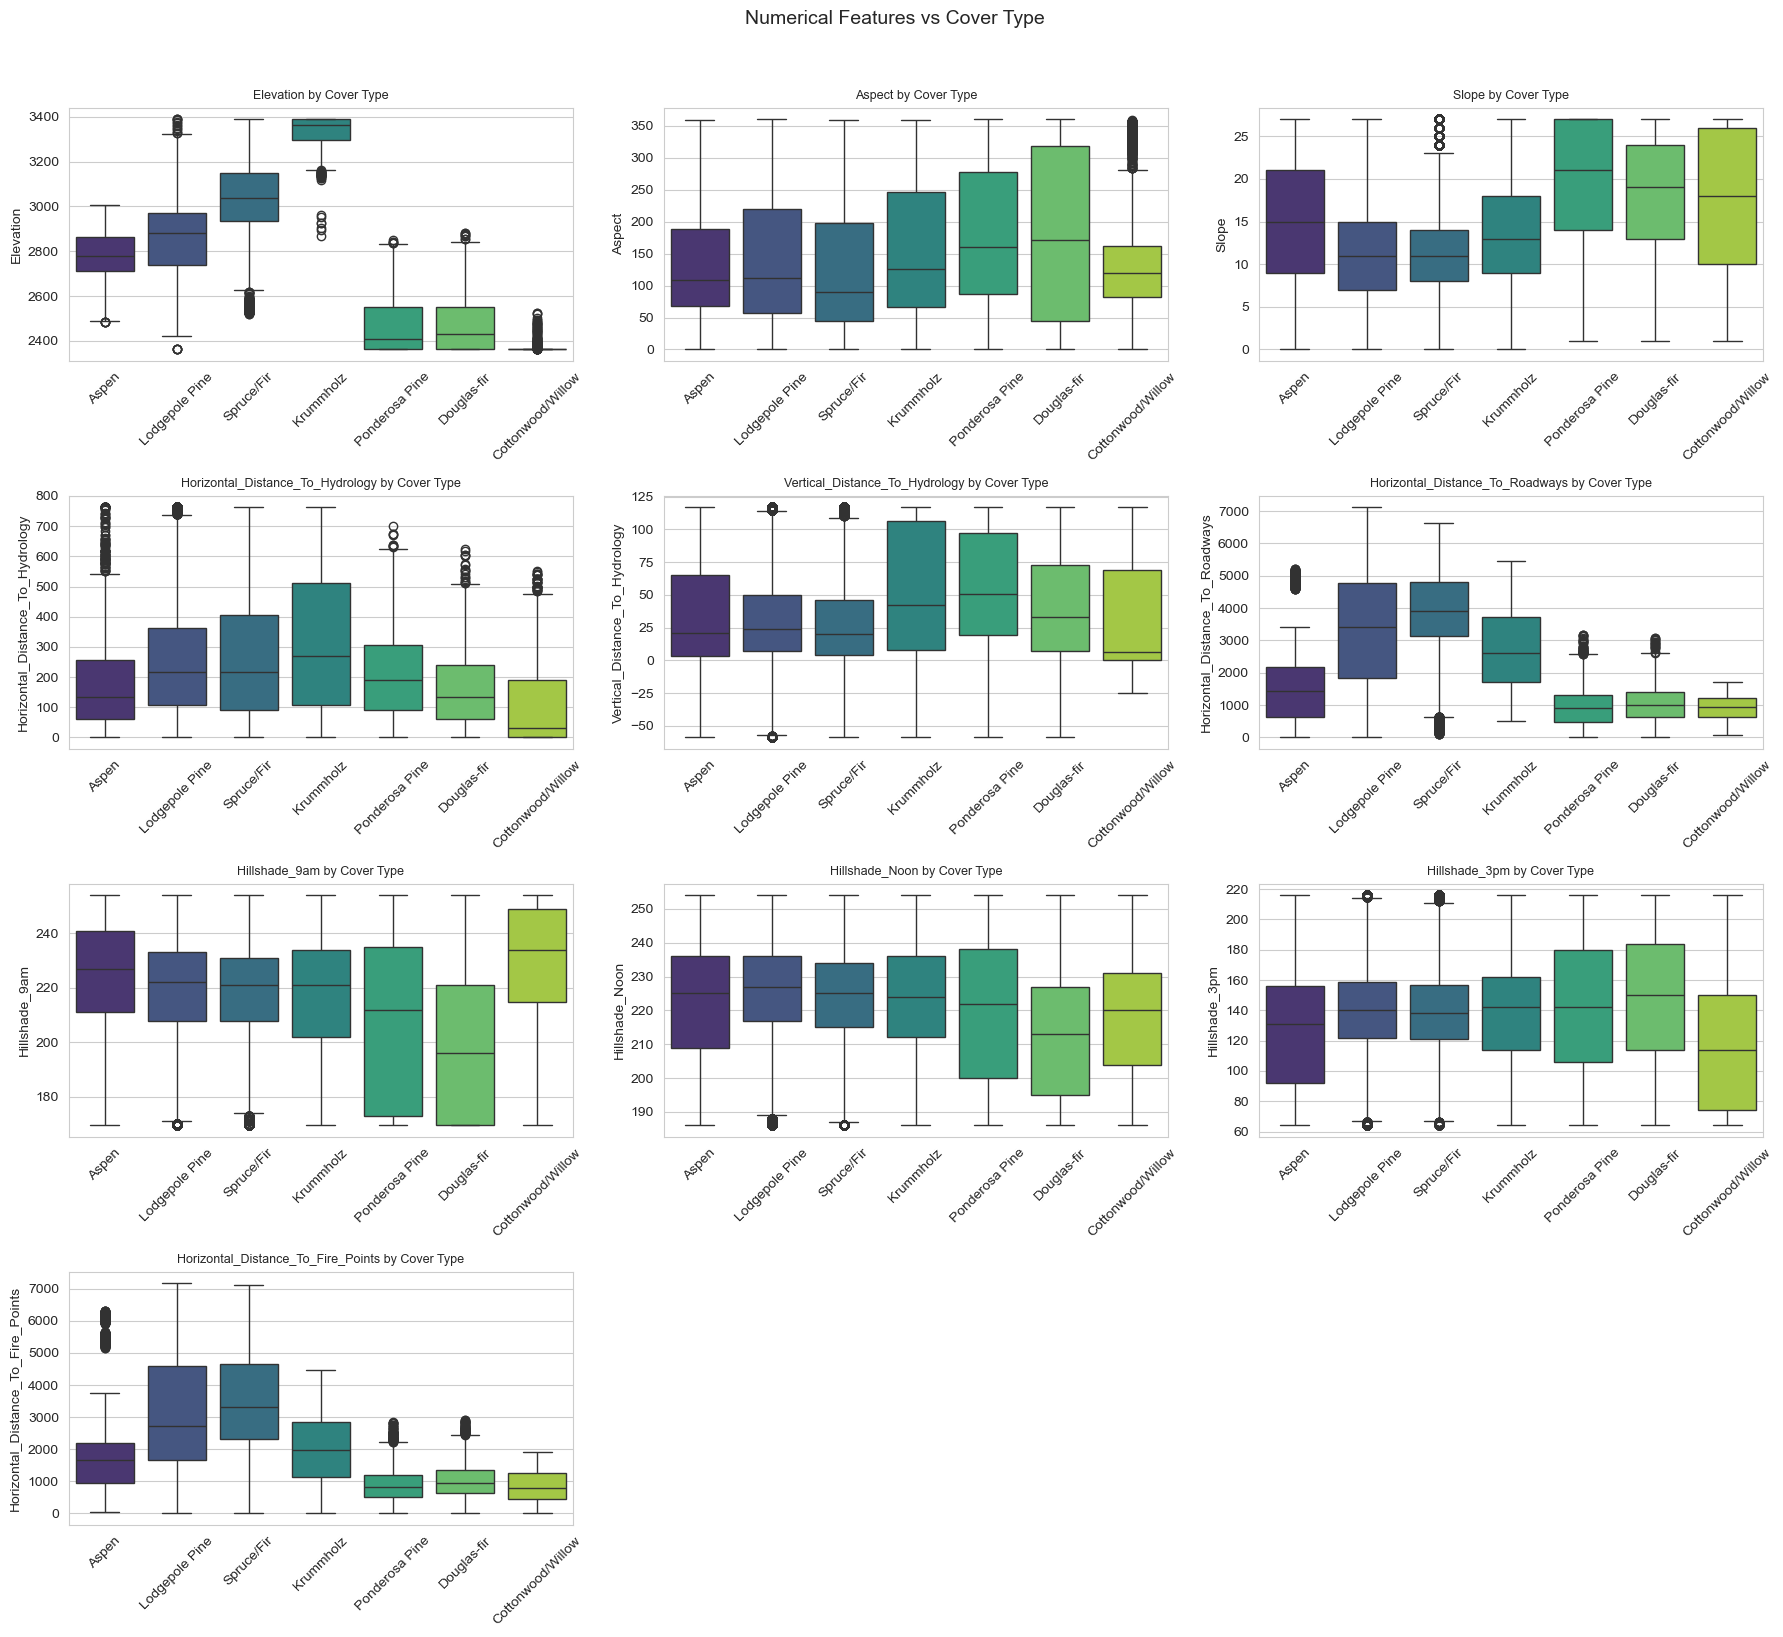

In [20]:
# Compare each numerical feature across all cover types

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Cover_Type', y=col, data=df, 
                palette='viridis', ax=axes[i])
    axes[i].set_title(f'{col} by Cover Type', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide the empty last subplot (we have 10 cols, grid has 12)
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Cover Type', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#  Correlation Heatmap

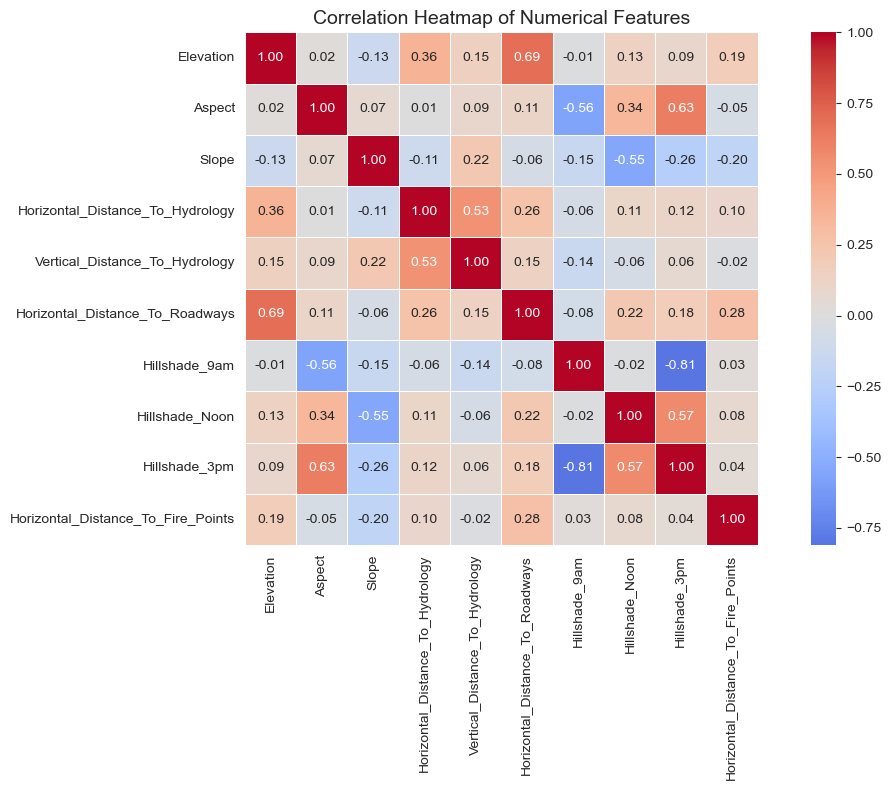

In [23]:
# Correlation shows how strongly two columns are related
# Values close to 1 or -1 = strong relationship
# Values close to 0 = weak relationship

plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, 
            annot=True,        # show numbers inside boxes
            fmt='.2f',         # round to 2 decimal places
            cmap='coolwarm',   # red=positive, blue=negative
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

# Wilderness Area Distribution

C:\Users\nihmath\AppData\Local\Temp\ipykernel_10068\3308419859.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Wilderness_Area', data=df, palette='Set2',


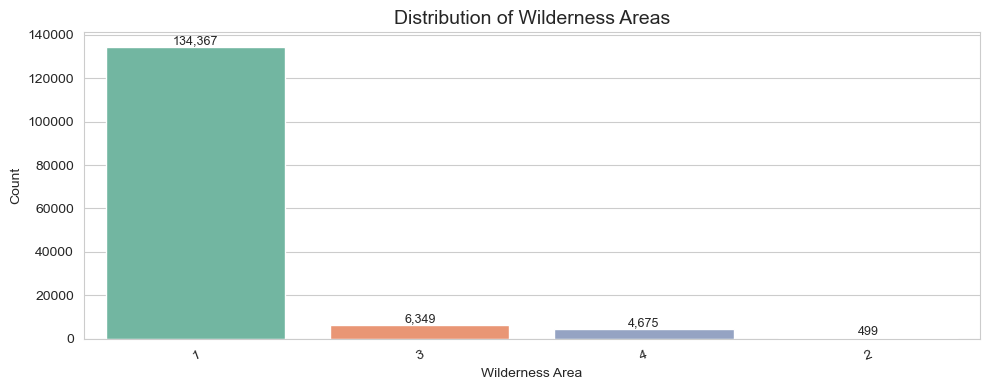

In [26]:
# How many samples from each Wilderness Area?

plt.figure(figsize=(10, 4))
ax = sns.countplot(x='Wilderness_Area', data=df, palette='Set2',
                   order=df['Wilderness_Area'].value_counts().index)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Distribution of Wilderness Areas', fontsize=14)
plt.xlabel('Wilderness Area')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Soil Type Distribution

C:\Users\nihmath\AppData\Local\Temp\ipykernel_10068\396860740.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Soil_Type', data=df, palette='tab20',


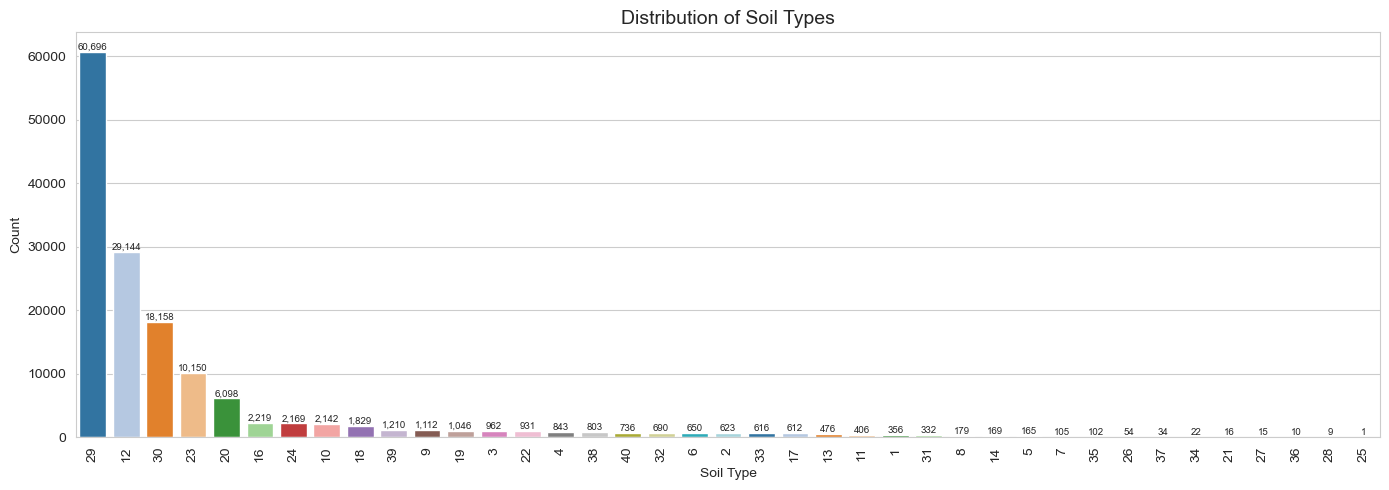

In [29]:
# How many samples from each Soil Type?

plt.figure(figsize=(14, 5))
ax = sns.countplot(x='Soil_Type', data=df, palette='tab20',
                   order=df['Soil_Type'].value_counts().index)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=7)

plt.title('Distribution of Soil Types', fontsize=14)
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Cover Type vs Wilderness Area

<Figure size 1200x500 with 0 Axes>

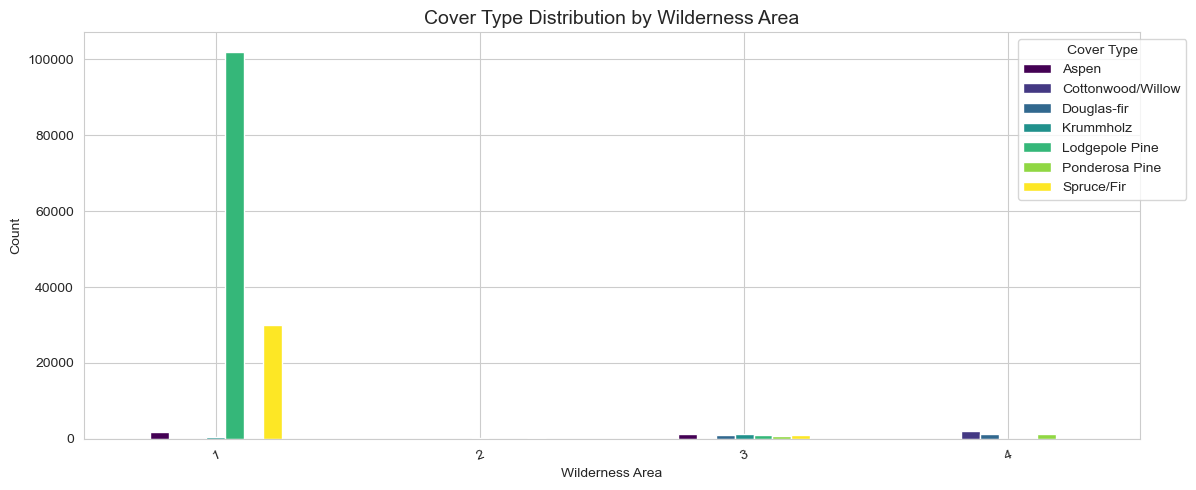

In [32]:
# Which wilderness area has which forest types?
# This helps us understand relationship between 
# categorical features and target

plt.figure(figsize=(12, 5))
ct = pd.crosstab(df['Wilderness_Area'], df['Cover_Type'])
ct.plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title('Cover Type Distribution by Wilderness Area', fontsize=14)
plt.xlabel('Wilderness Area')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.legend(title='Cover Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 📝 Summary from Notebook 3

- Loaded cleaned dataset: 145,891 rows × 13 columns
- Class imbalance confirmed visually — Lodgepole Pine dominates
- Elevation is a strong differentiator across forest cover types
- Strongest positive correlation: Elevation ↔ Horizontal_Distance_To_Roadways (0.69)
- Strongest negative correlation: Hillshade_9am ↔ Hillshade_3pm (-0.81)
- Hillshade_9am and Hillshade_3pm are highly correlated — may drop one later
- Aspect ↔ Hillshade_3pm also strongly correlated (0.63)
- Wilderness Area has strong relationship with Cover Type
- Next step: Notebook 4 - Feature Engineering